# Dimensionality Reduction applied to the OSM dataset

Adaptation of the `Copy_of_Tutorial8_DimReduction.ipynb` notebook (Iris) to the `all_cities_combined.csv` dataset.

**Project context:** evaluate whether OpenStreetMap data alone is enough to distinguish **Commercial** vs **Residential** zones across 6 US cities.
- 3 cities with ground truth (NYC, Philadelphia, Chicago) → official datasets (PLUTO, OPA, Cook County)
- 3 OSM-only cities (DC, SF, LA)

**Structure:**
1. PCA (Principal Component Analysis)
2. t-SNE
3. SOM (Self-Organizing Maps with MiniSom)

The target variable (`species` in Iris) is replaced by `zone_type` (Commercial / Residential).

Plots saved to `outputs/DimReduction/`.

## 1. Imports and configuration

In [135]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.3f' % x)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_style("darkgrid")

### Analysis configuration

**Parameters live in `config.py`** (same folder). Edit that file to change `SOURCE`, `CITIES`, `CITY_GROUP`, `BALANCE_METHOD`, `FEATURES`, `EXCLUDE_FEATURES`, paths, etc.

Both this notebook and `01_ShallowLearning_OSM.ipynb` read from the same `config.py`. After editing, do **Restart Kernel + Run All** so the new values apply.

In [ ]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path(r"E:\IAAC Local GIT Repositories\OSMnx-data-scraper\2026.05.25_ShallowLearning-Dimensionality_ramón")))

import importlib, config
importlib.reload(config)            # re-read config.py if you edited it without restart
from config import *

# This notebook saves outputs in the DimReduction subfolder
PLOTS_DIR = PLOTS_DIR_DIMRED
pathlib.Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)

print(f"SOURCE        = {SOURCE!r}")
print(f"CITIES        = {CITIES}")
print(f"CITY_GROUP    = {CITY_GROUP}")
print(f"BALANCE       = {BALANCE_METHOD}")
print(f"FEATURES      = {FEATURES}")
print(f"EXCLUDE       = {EXCLUDE_FEATURES}")
print(f"RANDOM_STATE  = {RANDOM_STATE}")
print(f"PLOTS_DIR     = {PLOTS_DIR}")

## 2. Load the dataset

In [ ]:
data_raw = pd.read_csv(CSV_PATH)
print("Original shape:", data_raw.shape)
data_raw.head()

### Apply city and class filters

1. Filter by cities using `CITIES` / `CITY_GROUP` from `config.py`.
2. Reduce to the two classes of the binary analysis: **Commercial** vs **Residential**.

In [ ]:
selected_cities = resolve_cities(data_raw['city'].unique())
print(f"Selected cities: {selected_cities}")

data = data_raw[data_raw['city'].isin(selected_cities)].copy()
data = data[data['zone_type'].isin(['Commercial', 'Residential'])].copy()
data = data.reset_index(drop=True)

print(f"\nShape after city + class filters: {data.shape}")
print(data['zone_type'].value_counts())

In [ ]:
print("Columns:", data_raw.columns.tolist())
print("Shape:", data_raw.shape)
data_raw.head(2)

### Class balancing

If `BALANCE_METHOD = 'undersample'`, take a random sample of the majority class equal to the size of the minority class. This prevents the Residential cloud from masking Commercial structure in PCA / t-SNE / SOM projections.

In [ ]:
if BALANCE_METHOD == 'undersample':
    n_min = data['zone_type'].value_counts().min()
    pieces = [
        data[data['zone_type'] == cls].sample(n=n_min, random_state=RANDOM_STATE)
        for cls in data['zone_type'].unique()
    ]
    data = pd.concat(pieces).reset_index(drop=True)
    print(f"After undersample: {len(data)} rows")
elif BALANCE_METHOD == 'none':
    print("No balancing applied.")
else:
    raise ValueError(f"Unknown BALANCE_METHOD: {BALANCE_METHOD!r}")

print("\nFinal zone_type distribution:")
print(data['zone_type'].value_counts())

## 3. Quick exploration

In [141]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 566 entries, 0 to 565
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   city                      566 non-null    str    
 1   cell_id                   566 non-null    str    
 2   cell_lat                  566 non-null    float64
 3   cell_lon                  566 non-null    float64
 4   zone_type                 566 non-null    str    
 5   cell_lot_count            566 non-null    int64  
 6   amenity_density           566 non-null    float64
 7   amenity_ratio_food_drink  566 non-null    float64
 8   avg_floors                562 non-null    float64
 9   avg_yearbuilt             562 non-null    float64
 10  total_bldg_area           562 non-null    float64
 11  building_count            562 non-null    float64
 12  landuse_entropy           566 non-null    float64
 13  shop_density_km2          566 non-null    float64
 14  office_density       

In [142]:
data.head()

,city,cell_id,cell_lat,cell_lon,zone_type,cell_lot_count,amenity_density,amenity_ratio_food_drink,avg_floors,avg_yearbuilt,total_bldg_area,building_count,landuse_entropy,shop_density_km2,office_density,road_density_primary,transit_stop_density,intersection_density,nightlife_density
0,NYC,r0014_c0022,40.706,-74.007,Commercial,7,2711.110,0.098,28.800,1958.000,5268199.000,10.000,0.931,577.780,44.440,20.540,311.110,222.220,0.000
1,NYC,r0057_c0037,40.764,-73.980,Commercial,14,622.220,0.286,22.800,1939.000,2356965.000,15.000,1.272,88.890,0.000,19.300,44.440,0.000,44.440
2,NYC,r0048_c0023,40.752,-74.005,Commercial,5,888.890,0.250,4.300,1900.000,195720.000,4.000,-0.000,44.440,44.440,8.140,44.440,133.330,44.440
3,NYC,r0053_c0032,40.759,-73.989,Commercial,15,1377.780,0.484,9.600,1936.000,1558140.000,17.000,1.286,311.110,0.000,23.360,311.110,133.330,222.220
4,NYC,r0039_c0029,40.740,-73.994,Commercial,14,933.330,0.191,8.400,1908.000,1172042.000,15.000,0.875,222.220,44.440,20.260,0.000,0.000,0.000


In [143]:
data.describe()

,cell_lat,cell_lon,cell_lot_count,amenity_density,amenity_ratio_food_drink,avg_floors,avg_yearbuilt,total_bldg_area,building_count,landuse_entropy,shop_density_km2,office_density,road_density_primary,transit_stop_density,intersection_density,nightlife_density
count,566.000,566.000,566.000,566.000,566.000,562.000,562.000,562.000,562.000,566.000,566.000,566.000,566.000,566.000,566.000,566.000
mean,40.768,-73.974,22.193,1129.093,0.191,10.313,1926.336,1260204.167,23.059,1.346,181.939,36.827,5.815,108.598,75.303,32.901
std,0.039,0.024,15.786,1649.350,0.181,7.593,23.656,959497.220,16.574,0.648,230.145,87.309,9.227,154.433,71.006,61.414
min,40.703,-74.015,3.000,0.000,0.000,1.700,1853.000,6735.000,1.000,-0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,40.742,-73.990,10.000,355.560,0.000,5.200,1912.000,521591.250,10.000,0.940,0.000,0.000,0.000,0.000,44.440,0.000
50%,40.759,-73.980,18.000,800.000,0.151,7.200,1925.000,963341.000,19.000,1.409,88.890,0.000,0.000,44.440,44.440,0.000
75%,40.792,-73.957,30.750,1455.558,0.315,12.900,1939.750,1867130.000,32.000,1.858,266.670,44.440,9.768,133.330,88.890,44.440
max,40.877,-73.908,83.000,30355.560,1.000,45.700,2018.000,5455446.000,85.000,2.636,1733.330,977.780,104.940,977.780,488.890,444.440


### Select numeric features

Identifiers (`city`, `cell_id`), coordinates (`cell_lat`, `cell_lon`) and the label (`zone_type`) are excluded.

In [ ]:
feature_cols = resolve_features()

if len(feature_cols) > 10:
    print(f"⚠ {len(feature_cols)} features. For Deep Learning ≤ 10 is recommended.")

print(f"Features used ({len(feature_cols)}):")
for f in feature_cols:
    print(f"  - {f}")

data_num = data[feature_cols].copy()
data_num = data_num.fillna(data_num.median(numeric_only=True))
print(f"\nShape of data_num: {data_num.shape}")

# --- Export filtered dataset(s) by SOURCE ---
pathlib.Path(EXPORT_DIR).mkdir(parents=True, exist_ok=True)

def _export(subset_name, cols):
    cols = [c for c in cols if c not in EXCLUDE_FEATURES]
    out = pd.concat([
        data[['city', 'cell_id', 'zone_type']].reset_index(drop=True),
        data[cols].fillna(data[cols].median(numeric_only=True)).reset_index(drop=True),
    ], axis=1)
    out_path = pathlib.Path(EXPORT_DIR) / f"dataset_{subset_name}.csv"
    out.to_csv(out_path, index=False, encoding='utf-8')
    print(f"  Saved: {out_path}  ({out.shape[0]} rows × {out.shape[1]} cols)")

print("\nExporting dataset(s):")
if SOURCE == 'property':
    _export('property', PROPERTY_FEATURES)
elif SOURCE == 'osm':
    _export('osm', OSM_FEATURES)
elif SOURCE == 'mixed':
    _export('property', PROPERTY_FEATURES)
    _export('osm', OSM_FEATURES)

data_num.head()

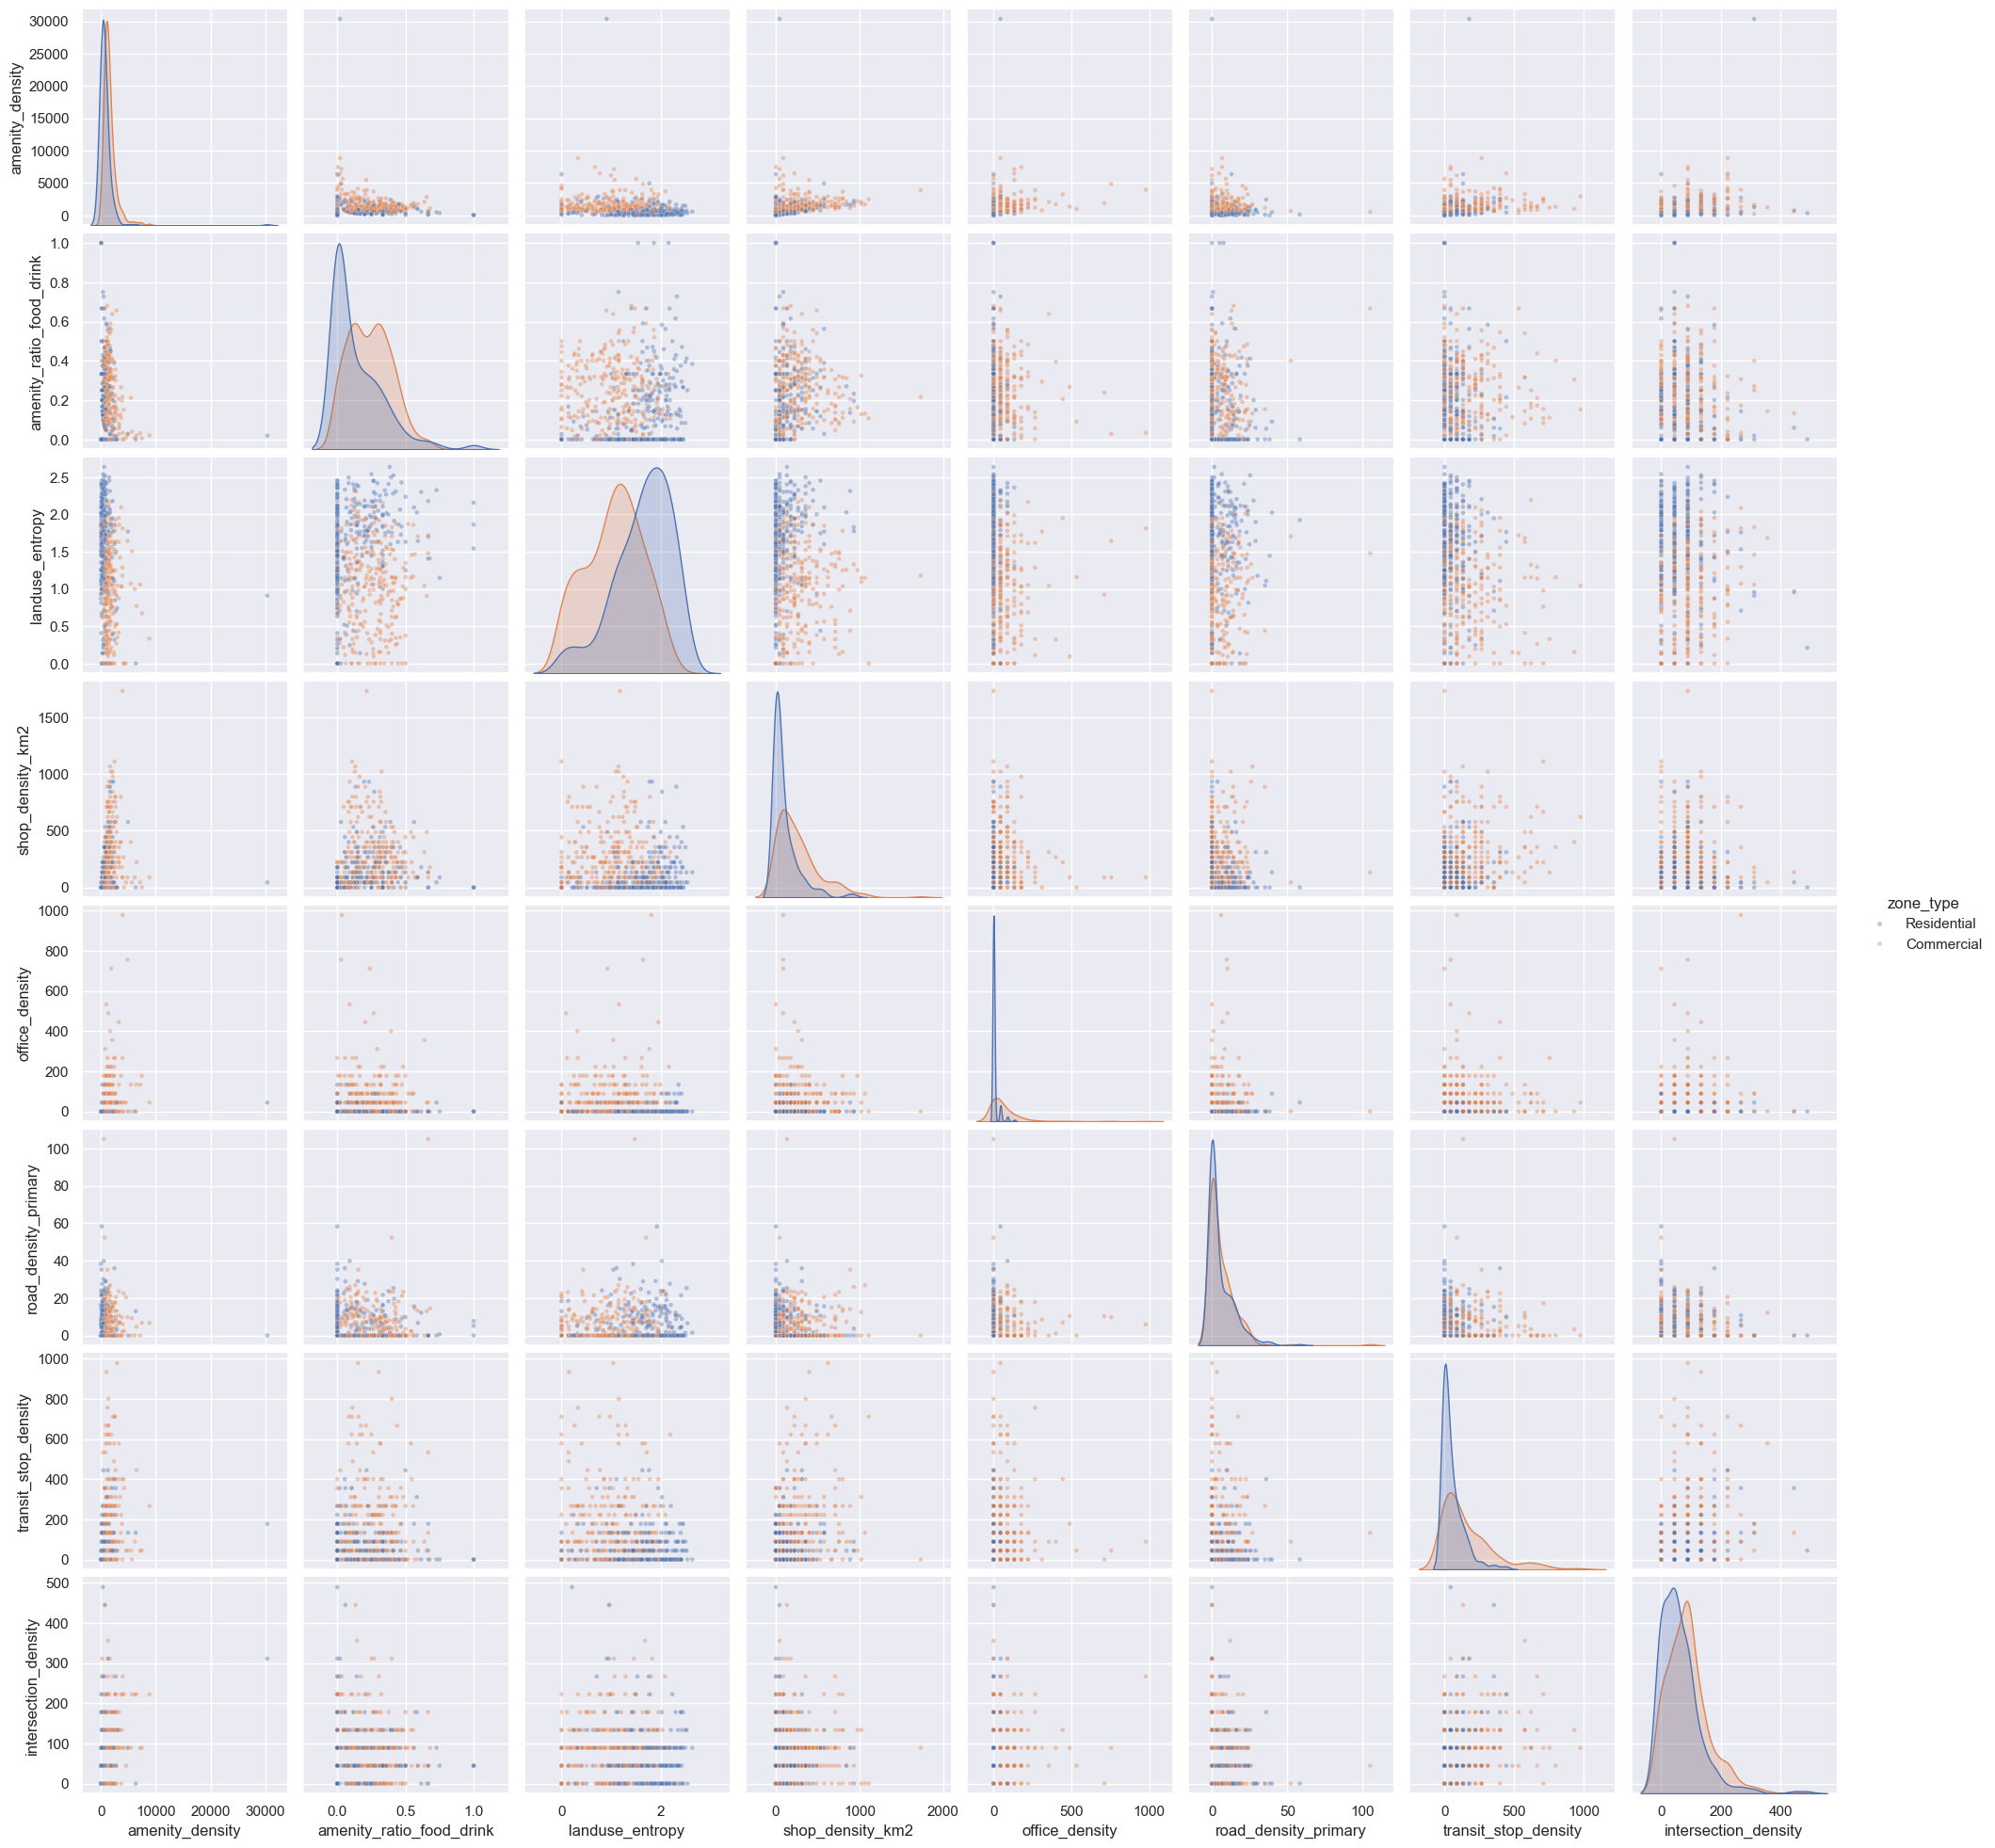

In [145]:
pairplot_n = min(2000, len(data_num))
pairplot_idx = data_num.sample(n=pairplot_n, random_state=RANDOM_STATE).index
sample_for_pairplot = pd.concat([
    data_num.loc[pairplot_idx],
    data.loc[pairplot_idx, ['zone_type']]
], axis=1)
sns.pairplot(sample_for_pairplot, hue='zone_type', plot_kws={'alpha': 0.4, 's': 12})

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(data_num.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix — OSM features')
plt.tight_layout()

## 4. Preprocessing — StandardScaler

$$StandardScale() = \frac{X-\mu}{\sigma}$$

In [147]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_num)

In [148]:
pd.DataFrame(data_scaled, columns=data_num.columns).describe()

,amenity_density,amenity_ratio_food_drink,landuse_entropy,shop_density_km2,office_density,road_density_primary,transit_stop_density,intersection_density
count,566.000,566.000,566.000,566.000,566.000,566.000,566.000,566.000
mean,0.000,0.000,-0.000,-0.000,0.000,-0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-0.685,-1.054,-2.080,-0.791,-0.422,-0.631,-0.704,-1.061
25%,-0.469,-1.054,-0.628,-0.791,-0.422,-0.631,-0.704,-0.435
50%,-0.200,-0.219,0.097,-0.405,-0.422,-0.631,-0.416,-0.435
75%,0.198,0.685,0.790,0.368,0.087,0.429,0.160,0.192
max,17.736,4.471,1.991,6.747,10.787,10.753,5.633,5.830


## 5. PCA

In [149]:
from sklearn.decomposition import PCA
model = PCA()
model.fit(data_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [ ]:
data_reduced = model.transform(data_scaled)
print("Projected shape:", data_reduced.shape)

### Explained variance

In [ ]:
plot_data = pd.DataFrame({
    'evr': model.explained_variance_ratio_,
    'cumsum_evr': np.cumsum(model.explained_variance_ratio_)
}).stack()
sns.set(rc={'figure.figsize': (15, 8)})
sns.lineplot(
    y=plot_data.values,
    x=plot_data.index.get_level_values(0),
    hue=plot_data.index.get_level_values(1)
)
plt.xlabel('Principal component')
plt.ylabel('Explained variance')
plt.title('Scree plot — PCA over OSM features')
plt.savefig(f"{PLOTS_DIR}/01_scree_{SOURCE}.png", dpi=150, bbox_inches='tight')
plt.show()

In [152]:
print(model.explained_variance_ratio_)

[0.2439757  0.14943851 0.12973983 0.11864813 0.10864564 0.10010553
 0.08403853 0.06540813]


### Biplots of the principal components

In [ ]:
def myplot(score, coeff, labels=None, hue_series=None, hue_name='zone_type',
           x_name='PC1', y_name='PC2'):
    plot_df = pd.DataFrame(score[:, 0:2], columns=[x_name, y_name])
    plot_df[hue_name] = hue_series.values

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=plot_df.sample(n=min(5000, len(plot_df)), random_state=RANDOM_STATE),
        x=x_name, y=y_name, hue=hue_name,
        palette='deep', s=20, edgecolor=None, alpha=0.5
    )

    n = coeff.shape[0]
    arrow_scale = 5
    for i in range(n):
        plt.arrow(0, 0,
                  arrow_scale * coeff[i, 0],
                  arrow_scale * coeff[i, 1],
                  color='red', alpha=0.7,
                  head_width=0.08, head_length=0.1, linewidth=1.2)
        label = data_num.columns[i] if labels is None else labels[i]
        plt.text(arrow_scale * coeff[i, 0] * 1.15,
                 arrow_scale * coeff[i, 1] * 1.15,
                 label, color='black', ha='center', va='center', fontsize=9)

    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.title(f'PCA Biplot — {x_name} vs {y_name} — Commercial vs Residential')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/02_biplot_{x_name}_{y_name}_{SOURCE}.png", dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
myplot(data_reduced[:, [0, 2]], np.transpose(model.components_[[0, 2], :]),
       hue_series=data['zone_type'], x_name='PC1', y_name='PC3')

In [ ]:
myplot(data_reduced[:, 2:4], np.transpose(model.components_[2:4, :]),
       hue_series=data['zone_type'], x_name='PC3', y_name='PC4')

In [ ]:
myplot(data_reduced[:, 0:2], np.transpose(model.components_[0:2, :]),
       hue_series=data['zone_type'], x_name='PC1', y_name='PC2')

In [ ]:
myplot(data_reduced[:, [1, 7]], np.transpose(model.components_[[1, 7], :]),
       hue_series=data['zone_type'], x_name='PC2', y_name='PC8')

### Loadings (how much each feature weighs in each PC)

In [155]:
pcscores = pd.DataFrame(data_reduced)
loadings = pd.DataFrame(model.components_, columns=data_num.columns)
loadings.index = ['PC' + str(i + 1) for i in range(len(pcscores.columns))]

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(loadings.transpose(), center=0, linewidths=0.5,
            cmap='bone', vmin=-1, vmax=1, annot=True, fmt='.2f')
plt.title('PCA loadings — OSM features')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/03_loadings_{SOURCE}.png", dpi=150, bbox_inches='tight')
plt.show()

### Pairplot of the top 4 PCs

With variance so spread out (PC1+PC2 capture only ~40%), it helps to see the **6 combinations** between PC1, PC2, PC3 and PC4 in a single chart. Cumsum up to PC4 ≈ 64%.

In [ ]:
n_pcs = min(4, data_reduced.shape[1])
pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

pcs_df = pd.DataFrame(data_reduced[:, :n_pcs], columns=pc_cols)
pcs_df['zone_type'] = data['zone_type'].values

g = sns.pairplot(
    pcs_df,
    vars=pc_cols,
    hue='zone_type',
    palette='deep',
    plot_kws={'alpha': 0.5, 's': 18, 'edgecolor': None},
    diag_kind='kde',
    height=2.5,
)

# --- Subtle loading arrows in each off-diagonal subplot ---
loadings_arr = model.components_              # (n_components, n_features)
feature_names = list(data_num.columns)
arrow_scale = 3.0                              # tweak if arrows look too short / too long
arrow_color = 'firebrick'
arrow_alpha = 0.35

for i in range(n_pcs):
    for j in range(n_pcs):
        if i == j:
            continue
        ax = g.axes[i][j]
        if ax is None:
            continue
        # x axis = PC(j+1), y axis = PC(i+1)
        for k, feat in enumerate(feature_names):
            dx = loadings_arr[j, k] * arrow_scale
            dy = loadings_arr[i, k] * arrow_scale
            ax.arrow(0, 0, dx, dy,
                     color=arrow_color, alpha=arrow_alpha,
                     head_width=0.08, head_length=0.10,
                     linewidth=0.8, length_includes_head=True)
            ax.text(dx * 1.08, dy * 1.08, feat,
                    color=arrow_color, alpha=arrow_alpha + 0.2,
                    ha='center', va='center', fontsize=6)

g.fig.suptitle(f'Pairplot — top {n_pcs} PCs × zone_type (with loadings)', y=1.02)
g.savefig(f"{PLOTS_DIR}/04_pairplot_PCs_{SOURCE}.png", dpi=120, bbox_inches='tight')
plt.show()

### Interactive 3D view (Plotly) — PC1 × PC2 × PC3

Rotatable 3D scatter. Captures **~52% of the variance** (vs 39% in 2D). Each point = one urban cell. You can:
- **Rotate** with click+drag
- **Zoom** with scroll
- **Hover** over a point to see its city, cell_id and coordinates in the 3 PCs
- **Click the legend** to hide/isolate a class

**Point size** is proportional to `cell_lot_count` (how many lots are in that cell) — bubble effect, gives you a 4th visual dimension.

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# DataFrame with PC1-PC3 + metadata for hover
pca3d_df = pd.DataFrame(data_reduced[:, :3], columns=['PC1', 'PC2', 'PC3'])
pca3d_df['zone_type'] = data['zone_type'].values
pca3d_df['city'] = data['city'].values
pca3d_df['cell_id'] = data['cell_id'].values

# Bubble size: use cell_lot_count if available; otherwise constant size
if 'cell_lot_count' in data.columns:
    pca3d_df['lot_count'] = data['cell_lot_count'].values.clip(min=1)
    size_arg = 'lot_count'
    size_max_arg = 18
else:
    size_arg = None
    size_max_arg = None

fig = px.scatter_3d(
    pca3d_df,
    x='PC1', y='PC2', z='PC3',
    color='zone_type',
    size=size_arg,
    size_max=size_max_arg,
    hover_data=['city', 'cell_id'],
    opacity=0.6,
    color_discrete_map={'Commercial': '#FF7F50', 'Residential': '#4682B4'},
    title=f'PCA 3D with loadings — PC1/PC2/PC3 (cumsum ≈ {sum(model.explained_variance_ratio_[:3])*100:.1f}%)',
)
fig.update_traces(marker=dict(line=dict(width=0)))

# --- 3D loading arrows ---
loadings_3d = model.components_[:3, :]      # (3, n_features)
feature_names = list(data_num.columns)
# Auto scale: arrows reach ~60% of the cloud's max
cloud_max = float(np.abs(data_reduced[:, :3]).max())
loading_max = float(np.abs(loadings_3d).max()) + 1e-9
arrow_scale = cloud_max * 0.6 / loading_max

for k, feat in enumerate(feature_names):
    dx = float(loadings_3d[0, k] * arrow_scale)
    dy = float(loadings_3d[1, k] * arrow_scale)
    dz = float(loadings_3d[2, k] * arrow_scale)

    # Line from origin
    fig.add_trace(go.Scatter3d(
        x=[0, dx], y=[0, dy], z=[0, dz],
        mode='lines',
        line=dict(color='firebrick', width=4),
        showlegend=False,
        hoverinfo='skip',
    ))

    # Cone = arrowhead at the tip
    fig.add_trace(go.Cone(
        x=[dx], y=[dy], z=[dz],
        u=[dx], v=[dy], w=[dz],
        sizemode='absolute',
        sizeref=arrow_scale * 0.15,
        anchor='tip',
        colorscale=[[0, 'firebrick'], [1, 'firebrick']],
        showscale=False,
        hoverinfo='skip',
    ))

    # Feature label
    fig.add_trace(go.Scatter3d(
        x=[dx * 1.12], y=[dy * 1.12], z=[dz * 1.12],
        mode='text',
        text=[feat],
        textfont=dict(color='firebrick', size=11),
        showlegend=False,
        hoverinfo='skip',
    ))

fig.update_layout(
    width=950, height=750,
    scene=dict(
        xaxis_title=f'PC1 ({model.explained_variance_ratio_[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({model.explained_variance_ratio_[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({model.explained_variance_ratio_[2]*100:.1f}%)',
        aspectmode='cube',
    ),
    legend=dict(itemsizing='constant'),
)
fig.show()

### Bonus — t-SNE in 3D

t-SNE preserves local structure better than PCA, so in 3D it usually shows clearer clusters. It can reveal groups of cells that "stick together" in the original space even when PCA spreads them out.

In [ ]:
from sklearn.manifold import TSNE

TSNE3D_SAMPLE = min(8000, len(data_num))
tsne3d_idx = data_num.sample(n=TSNE3D_SAMPLE, random_state=RANDOM_STATE).index

perplexity_3d = 30 if len(tsne3d_idx) >= 100 else max(5, len(tsne3d_idx) // 4)
tsne3d = TSNE(n_components=3, random_state=RANDOM_STATE, perplexity=perplexity_3d, init='pca')
tsne3d_results = tsne3d.fit_transform(data_scaled[tsne3d_idx])

tsne3d_df = pd.DataFrame(tsne3d_results, columns=['TSNE-1', 'TSNE-2', 'TSNE-3'])
tsne3d_df['zone_type'] = data.loc[tsne3d_idx, 'zone_type'].values
tsne3d_df['city']      = data.loc[tsne3d_idx, 'city'].values
tsne3d_df['cell_id']   = data.loc[tsne3d_idx, 'cell_id'].values

fig = px.scatter_3d(
    tsne3d_df,
    x='TSNE-1', y='TSNE-2', z='TSNE-3',
    color='zone_type',
    hover_data=['city', 'cell_id'],
    opacity=0.7,
    color_discrete_map={'Commercial': '#FF7F50', 'Residential': '#4682B4'},
    title='t-SNE 3D — Commercial vs Residential',
)
fig.update_traces(marker=dict(size=4, line=dict(width=0)))
fig.update_layout(width=900, height=700, legend=dict(itemsizing='constant'))
fig.show()

### 2D view of the 3D t-SNE — TSNE-1 (X) vs TSNE-3 (Y)

Flat projection of the same 3D t-SNE, discarding TSNE-2. Useful when the 3D clusters look better from a specific angle.

In [ ]:
fig = px.scatter(
    tsne3d_df,
    x='TSNE-1', y='TSNE-3',
    color='zone_type',
    hover_data=['city', 'cell_id', 'TSNE-2'],
    opacity=0.7,
    color_discrete_map={'Commercial': '#FF7F50', 'Residential': '#4682B4'},
    title='t-SNE — TSNE-1 (horizontal) × TSNE-3 (vertical)',
)
fig.update_traces(marker=dict(size=7, line=dict(width=0)))
fig.update_layout(
    width=900, height=700,
    xaxis_title='TSNE-1',
    yaxis_title='TSNE-3',
    legend=dict(itemsizing='constant'),
)
fig.show()

## 6. t-SNE

t-SNE is computationally expensive. We use a subsample of up to 8,000 points.

In [ ]:
from sklearn.manifold import TSNE

TSNE_SAMPLE = min(8000, len(data_num))
tsne_idx = data_num.sample(n=TSNE_SAMPLE, random_state=RANDOM_STATE).index

features_tsne = data_scaled[tsne_idx]
labels_tsne = data.loc[tsne_idx, 'zone_type']

# If len(features_tsne) < 100, lower perplexity (e.g. 5-15) to avoid warnings
perplexity = 30 if len(features_tsne) >= 100 else max(5, len(features_tsne) // 4)
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=perplexity, init='pca')
tsne_results = tsne.fit_transform(features_tsne)

In [158]:
tsne_df = pd.DataFrame(tsne_results, columns=['TSNE-1', 'TSNE-2'])
tsne_df['zone_type'] = labels_tsne.values
tsne_df.head()

,TSNE-1,TSNE-2,zone_type
0,-5.759,-23.532,Residential
1,-5.731,-24.937,Residential
2,3.806,15.005,Commercial
3,-1.336,2.279,Residential
4,-9.069,4.460,Residential


In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=tsne_df,
    x='TSNE-1', y='TSNE-2',
    hue='zone_type', palette='deep',
    s=20, alpha=0.6, edgecolor=None
)
plt.title('t-SNE — Commercial vs Residential (OSM features)')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/05_tsne2d_{SOURCE}.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. SOM (MiniSom)

In [ ]:
# If not installed, uncomment the following line:
# !pip install minisom

In [161]:
from sklearn.preprocessing import MinMaxScaler

SOM_SAMPLE = min(8000, len(data_num))
som_idx = data_num.sample(n=SOM_SAMPLE, random_state=RANDOM_STATE).index

minmax = MinMaxScaler()
X_scaled = minmax.fit_transform(data_num.loc[som_idx])
labels_som = data.loc[som_idx, 'zone_type'].values

In [162]:
from minisom import MiniSom

som_size = (10, 10)
som = MiniSom(x=som_size[0], y=som_size[1],
              input_len=X_scaled.shape[1],
              sigma=1.0, learning_rate=0.5, random_seed=RANDOM_STATE)
som.train(X_scaled, num_iteration=2000, verbose=True)

 [ 2000 / 2000 ] 100% - 0:00:00 left 
 quantization error: 0.15218046591591175


In [163]:
y = labels_som
label_to_int = {label: idx for idx, label in enumerate(np.unique(y))}
y_numeric = [label_to_int[label] for label in y]
print(label_to_int)

{'Commercial': 0, 'Residential': 1}


In [ ]:
plt.figure(figsize=(10, 10))
for i, x in enumerate(X_scaled):
    w = som.winner(x)
    plt.text(w[0] + 0.5, w[1] + 0.5,
             '.' if y[i] == 'Residential' else 'x',
             color=plt.cm.Set1(y_numeric[i] / max(len(label_to_int), 2)),
             fontdict={'size': 12})

plt.xlim([0, som_size[0]])
plt.ylim([0, som_size[1]])
plt.title('SOM — OSM features (. = Residential,  x = Commercial)')
plt.grid(True)
plt.savefig(f"{PLOTS_DIR}/06_som_mapping_{SOURCE}.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Distance map (U-matrix)
plt.figure(figsize=(10, 10))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Inter-neuron distance')
plt.title('U-Matrix — SOM')
plt.savefig(f"{PLOTS_DIR}/07_som_umatrix_{SOURCE}.png", dpi=150, bbox_inches='tight')
plt.show()